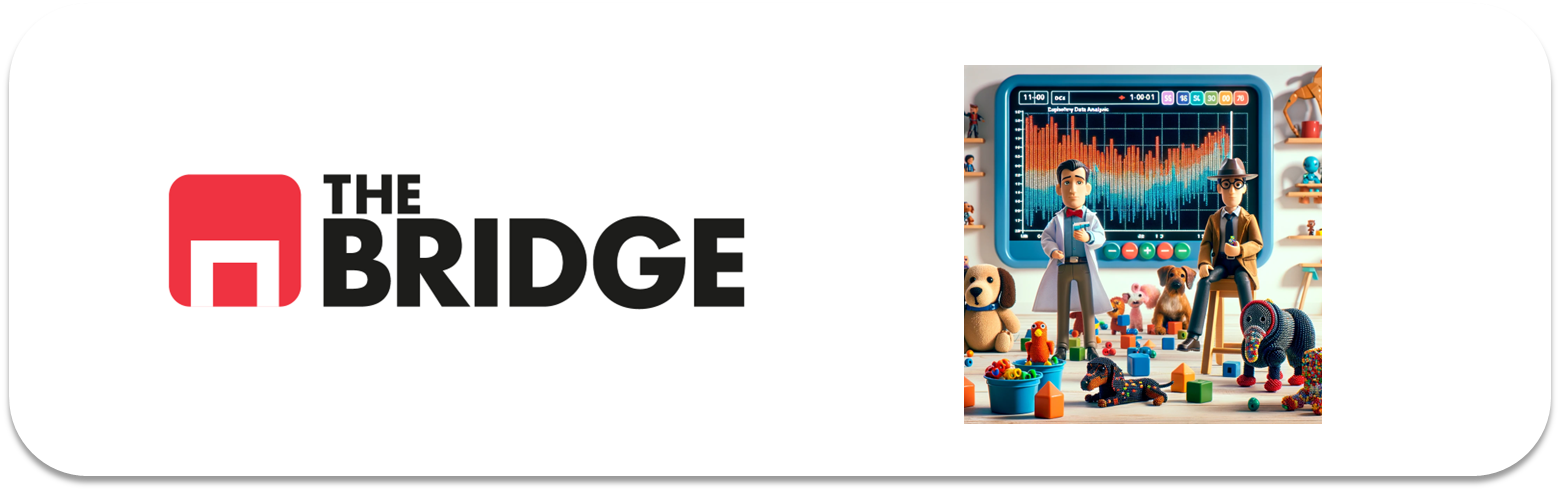

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_relationship_fin, plot_categorical_numerical_relationship, plot_combined_graphs, plot_grouped_boxplots, plot_grouped_histograms, grafico_dispersion_con_correlacion, bubble_plot

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [99]:
df_titanic = pd.read_csv("./data/titanic.csv")

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [100]:
df_titanic = df_titanic.drop(["deck","survived","pclass","embarked"], axis=1)

In [101]:
df_titanic

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [102]:
df_titanic["family_members"] = (df_titanic["parch"] + df_titanic["sibsp"])

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [103]:
df_titanic["embark_town"] = df_titanic["embark_town"].fillna(df_titanic["embark_town"].mode()[0])

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [104]:
df_titanic["age"] = df_titanic["age"].fillna(df_titanic.groupby("who")["age"].transform("mean"))

In [105]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             891 non-null    str    
 1   age             891 non-null    float64
 2   sibsp           891 non-null    int64  
 3   parch           891 non-null    int64  
 4   fare            891 non-null    float64
 5   class           891 non-null    str    
 6   who             891 non-null    str    
 7   adult_male      891 non-null    bool   
 8   embark_town     891 non-null    str    
 9   alive           891 non-null    str    
 10  alone           891 non-null    bool   
 11  family_members  891 non-null    int64  
dtypes: bool(2), float64(2), int64(3), str(5)
memory usage: 71.5 KB


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

##### **1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?**

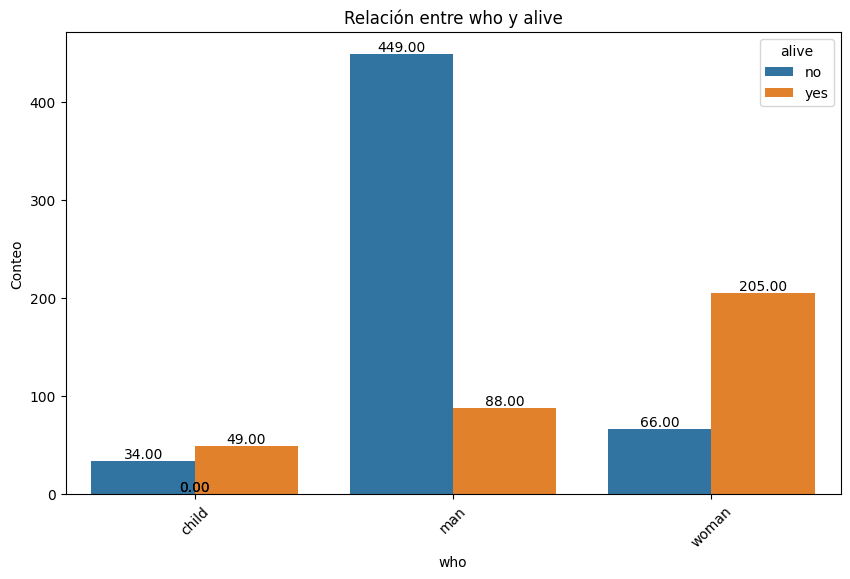

In [106]:
plot_categorical_relationship_fin(df_titanic, "who","alive", show_values= True)

Como se observa en el gráfico, en términos absolutos, el número de hombres que sobrevivieron es superior al de los niños. No obstante, el grupo con mayor número de supervivientes es el de las mujeres.

Al analizar los valores de quienes no sobrevivieron, se detecta la necesidad de estudiar los datos en términos relativos, ya que el grupo con mayor número de fallecidos es el de los hombres.

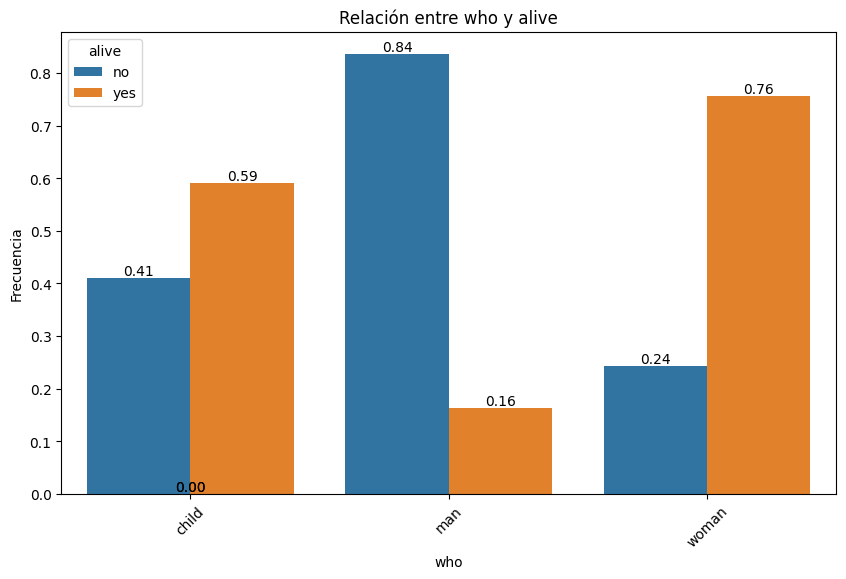

In [107]:
plot_categorical_relationship_fin(df_titanic,"who","alive", relative_freq=True, show_values= True)

Tras analizar los valores en términos relativos dentro de cada grupo, observamos diferencias claras en la probabilidad de supervivencia. En el caso de los hombres, aproximadamente el 84% fallecieron, mientras que solo un 16% lograron sobrevivir. 

Por el contrario, las mujeres presentan una situación inversa, con una tasa de supervivencia cercana al 76% frente a un 24% de fallecimientos. En el caso de los niños, la mayoría también sobrevive, con una tasa aproximada del 59%.

Estos resultados evidencian que la probabilidad de supervivencia varía significativamente según el grupo, siendo considerablemente menor en hombres en comparación con mujeres y niños.

Con el fin de determinar si el hecho de ser hombre, mujer o niño está relacionado con la probabilidad de supervivencia, se procede a calcular el estadístico Chi-Cuadrado, el P-Value, los grados de libertad y la tabla de frecuencias esperadas. Previamente, se construye la tabla de contingencia.

In [108]:
tabla_contingencia_ala_who = pd.crosstab(df_titanic['alive'], df_titanic['who'])

tabla_contingencia_ala_who

who,child,man,woman
alive,,,
no,34,449,66
yes,49,88,205


In [109]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia_ala_who)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


Existe una diferencia muy grande entre las frecuencias observadas y las esperadas en el caso de que las variables fueran independientes, por lo que hay evidencia estadísticamente significativa de que existe relación entre who y survived. El valor Chi-Cuadrado es muy elevado (283.92), lo que indica una desviación considerable respecto a la hipótesis de independencia, y al obtener un P-Value muy cercano a 0 se concluye que dicha desviación no es fruto del azar, sino de la dependencia entre ambas variables.

Si observamos los datos de la Tabla de Frecuencias Esperadas, vemos que todos los valores esperados en caso de que fueran variables independientes están notablemente por encima o por debajo de los valores obtenidos.

Tras determinar que existe dependencia entre los valores de la varible `who` y la probabilidad de superviviencia, pasamos a analizar si existe relación entre el sexo del pasajero y la probabilidad de superviviencia.

In [110]:
tabla_contingencia_sex = pd.crosstab(df_titanic['alive'], df_titanic['sex'])
tabla_contingencia_sex

sex,female,male
alive,,
no,81,468
yes,233,109


In [111]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia_sex)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 260.71702016732104
P-Value: 1.1973570627755645e-58
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[193.47474747 355.52525253]
 [120.52525253 221.47474747]]


Con la obtención de estos resultados, se observa nuevamente evidencia de relación entre `sex` y `alive`, en línea con lo analizado previamente para `who`. El elevado valor Chi-Cuadrado (260.72) indica una notable desviación entre las frecuencias observadas y las esperadas bajo el supuesto de independencia, y el p-value prácticamente nulo confirma que dicha relación es estadísticamente significativa.

Para determinar si existe relación entre ser adulto o ser niño con respecto a la probabilidad de supervivencia, creamos una nueva columna en el DataFrame categórica binaria, en la que se va a reflejar si es pasajero es adulto (male y female = True) o no (child = False).

In [112]:
df_titanic["is_adult"] = df_titanic["who"].isin(["man", "woman"])

In [113]:
tabla_contingencia_is_adult = pd.crosstab(df_titanic['alive'], df_titanic['is_adult'])
tabla_contingencia_is_adult

is_adult,False,True
alive,,
no,34,515
yes,49,293


In [114]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia_is_adult)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 15.556993340077092
P-Value: 8.005497211300105e-05
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 497.85858586]
 [ 31.85858586 310.14141414]]


El análisis muestra que existe relación entre ser adulto o niño y la probabilidad de supervivencia. No obstante, dicha relación es más débil en comparación con la observada previamente para las variables `sex` y `who`, como refleja el menor valor Chi-Cuadrado (15.55), aunque sigue siendo estadísticamente significativa.

##### **2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?**

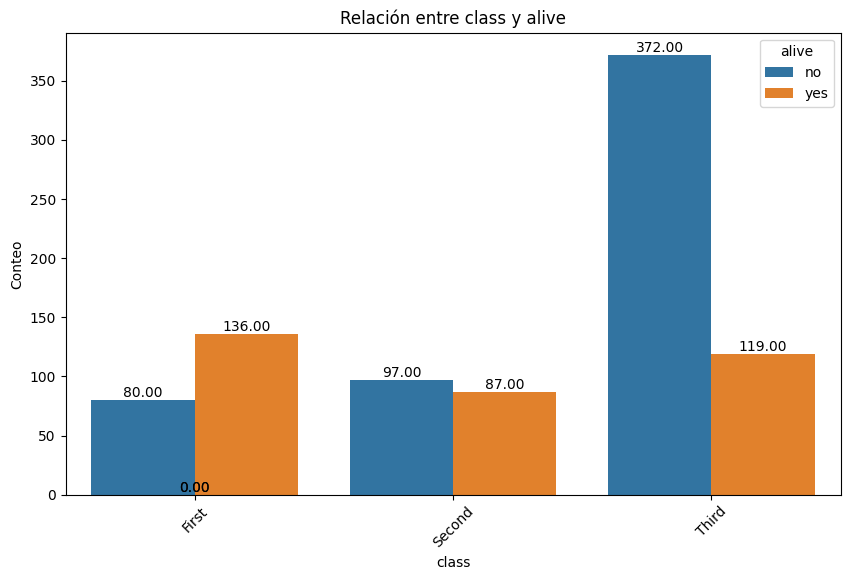

In [115]:
plot_categorical_relationship_fin(df_titanic, "class","alive", show_values= True)

Teniendo en cuenta el estudio de supervivencia y mortalidad según clases en términos absolutos, observamos que en la primera clase se registra el menor número de fallecidos y el mayor número de supervivientes. 

Llama especialmente la atención la cantidad de fallecidos en tercera clase, siendo superior al doble de la suma de fallecidos de las otras dos clases.

La clase que presenta una mayor igualdad entre el número de fallecidos y el número de supervivientes es la segunda clase, aunque con un menor número de supervivientes que la primera.

A partir de estos datos, se comienza a observar la posible existencia de una relación entre la clase del pasajero y la supervivencia. No obstante, al tratarse de valores absolutos, será necesario analizar los datos en términos relativos para confirmar esta relación.

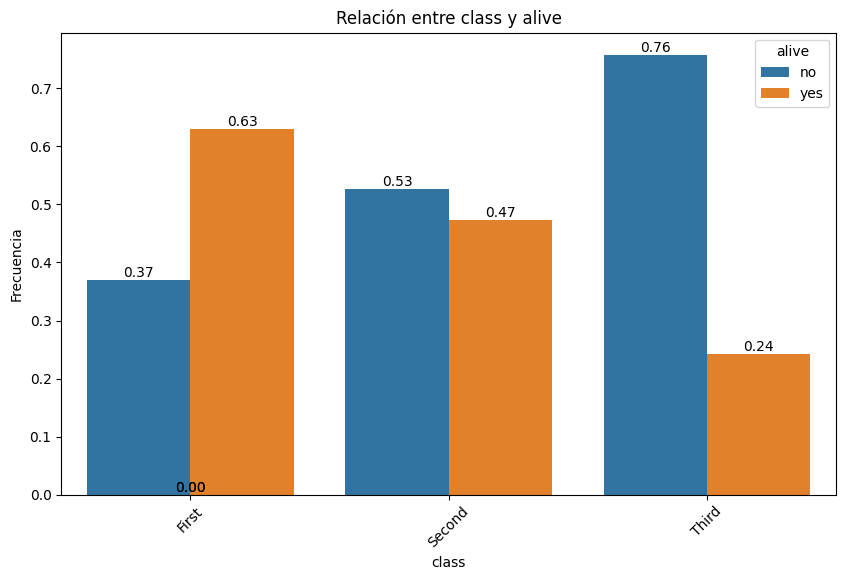

In [116]:
plot_categorical_relationship_fin(df_titanic, "class","alive", relative_freq=True, show_values= True)

En términos relativos, se observa que los pasajeros de tercera clase presentan una probabilidad de fallecer cercana al 76%, mientras que en primera clase este porcentaje desciende aproximadamente al 37%. 

Esta diferencia confirma que la probabilidad de supervivencia varía de forma notable en función de la clase del pasajero, lo que refuerza la existencia de una relación entre ambas variables.

Procedemos a calcular a través de la tabla de contingencia y sus valores de Chi-Cuadrado, P-Value, Grados de Libertad y Tabla de Frecuencias Esperadas:

In [117]:
tabla_contingencia_class = pd.crosstab(df_titanic['alive'], df_titanic['class'])
tabla_contingencia_class

class,First,Second,Third
alive,,,
no,80,97,372
yes,136,87,119


In [118]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia_class)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


Tras la obtención de estos resultados, se confirma la existencia de una relación estadísticamente significativa entre las variables `alive` y `class`. 

Al analizar las frecuencias esperadas, se observa que en la segunda clase las diferencias entre valores observados y esperados son menores en comparación con las otras clases. Sin embargo, en la primera y tercera clase estas diferencias son más pronunciadas, lo que indica una mayor desviación respecto a la hipótesis de independencia y, por tanto, evidencia de dependencia entre ambas variables.

##### **3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?**

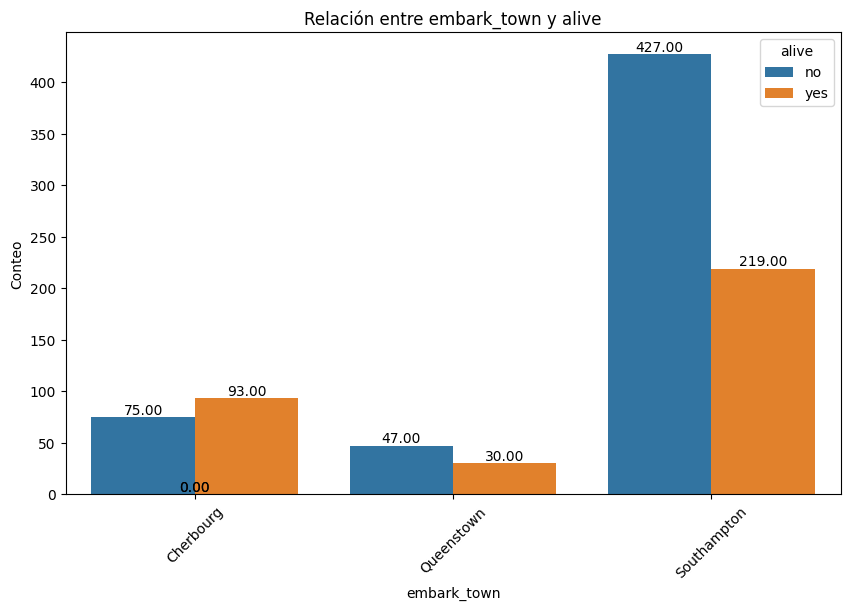

In [119]:
plot_categorical_relationship_fin(df_titanic, "embark_town","alive", show_values= True)

A partir del análisis en términos absolutos, observamos que entre las ciudades de embarque Southampton presenta tanto el mayor número de supervivientes como de fallecidos. Esto sugiere que el volumen de pasajeros que embarcaron en Southampton es superior al de Cherbourg o Queenstown.

Dada esta situación, resulta necesario analizar los datos en términos relativos para evaluar adecuadamente la relación entre la ciudad de embarque y la supervivencia.

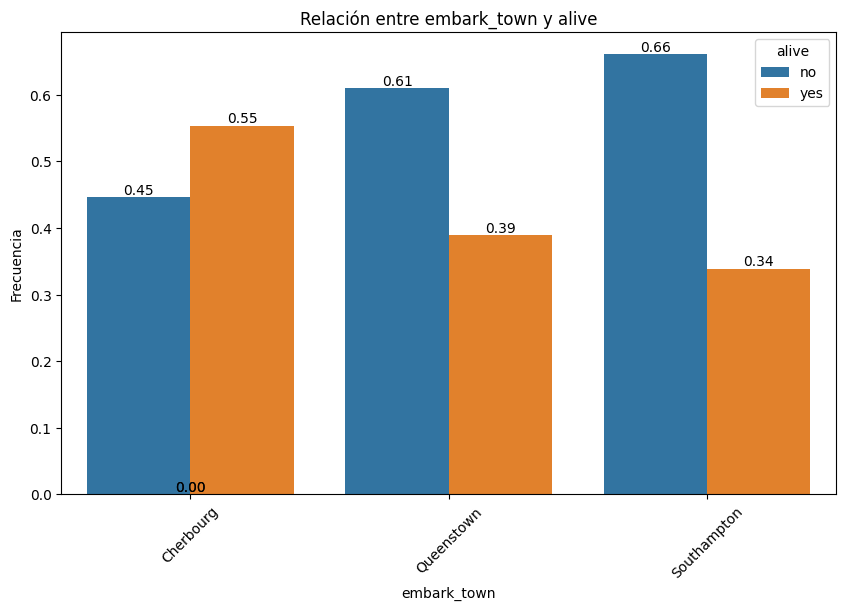

In [120]:
plot_categorical_relationship_fin(df_titanic, "embark_town","alive", relative_freq=True, show_values= True)

En términos relativos, se observa que la distribución de pasajeros que sobrevivieron y los que no en Queenstown y Southampton es bastante similar, con porcentajes de fallecidos del 61% y 66% respectivamente, en ambos casos superiores a los de supervivientes.

Sin embargo, la situación cambia en el caso de Cherbourg, donde aproximadamente el 55% de los pasajeros sobrevivieron, invirtiendo la tendencia observada en las otras ciudades.

Este resultado plantea nuevas cuestiones relevantes para el análisis: ¿a qué clase pertenecían mayoritariamente los pasajeros que embarcaron en Cherbourg? ¿Qué perfil presentaban en términos de edad?

In [121]:
tabla_contingencia_embark = pd.crosstab(df_titanic['alive'], df_titanic['embark_town'])
tabla_contingencia_embark

embark_town,Cherbourg,Queenstown,Southampton
alive,,,
no,75,47,427
yes,93,30,219


In [122]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia_embark)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]


Los resultados obtenidos indican que existe relación entre ambas variables, al obtener un p-value muy cercano a 0, lo que permite rechazar la hipótesis de independencia.

No obstante, el valor del estadístico Chi-Cuadrado, a pesar de ser elevado, es inferior al observado en análisis anteriores, lo que sugiere que la relación es menos marcada en comparación con otras variables estudiadas.

Además, al analizar las frecuencias esperadas, se observa que en Southampton y Queenstown las diferencias respecto a los valores observados son reducidas. Por el contrario, en Cherbourg estas diferencias crecen, lo que indica que la dependencia entre las variables se concentra principalmente en los pasajeros que embarcaron en esta ciudad.

##### **4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?**

(2,)


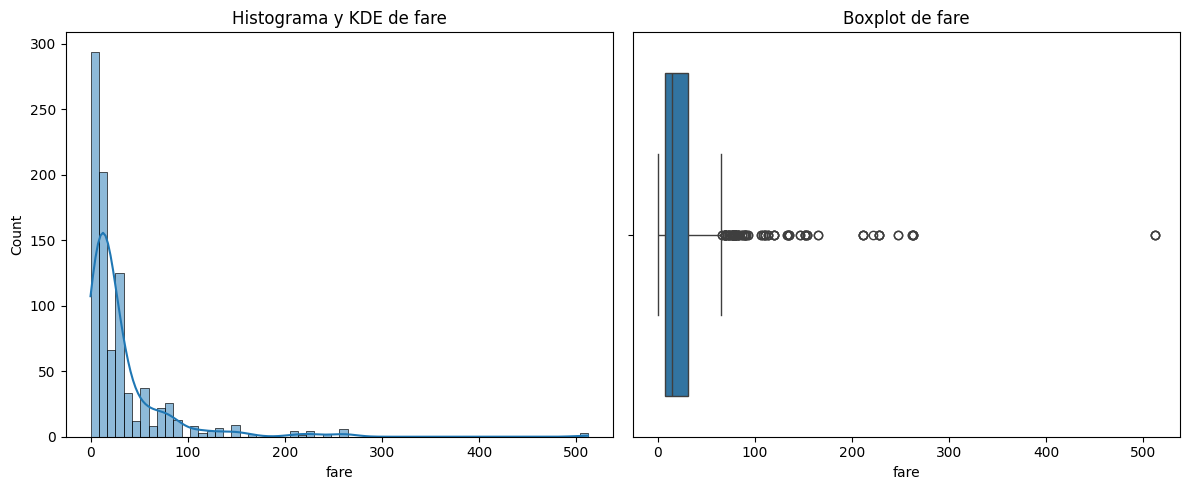

In [123]:
plot_combined_graphs(df_titanic,["fare"])

Dada la elevada dispersión y asimetría presentes en la variable `fare`, se opta por utilizar la mediana como medida representativa para analizar la posible relación entre el precio del billete y la probabilidad de supervivencia.

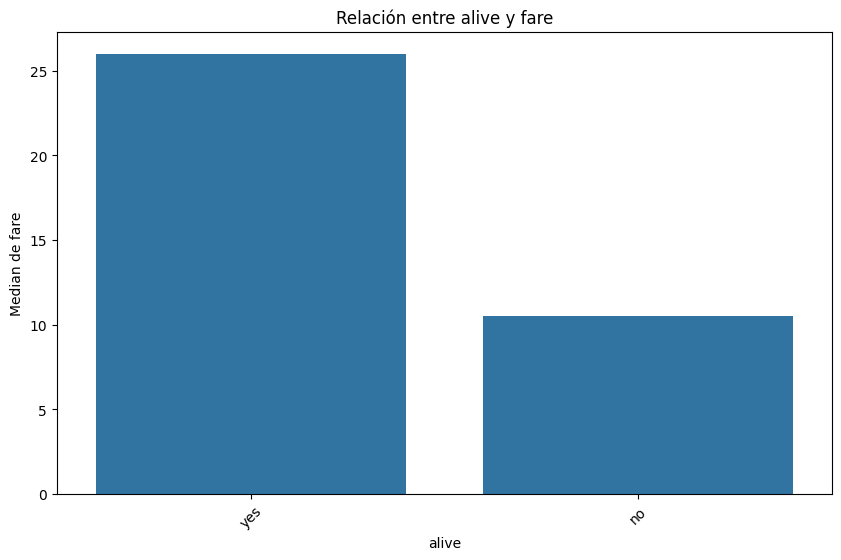

In [124]:
plot_categorical_numerical_relationship(df_titanic,"alive","fare", measure = "median")

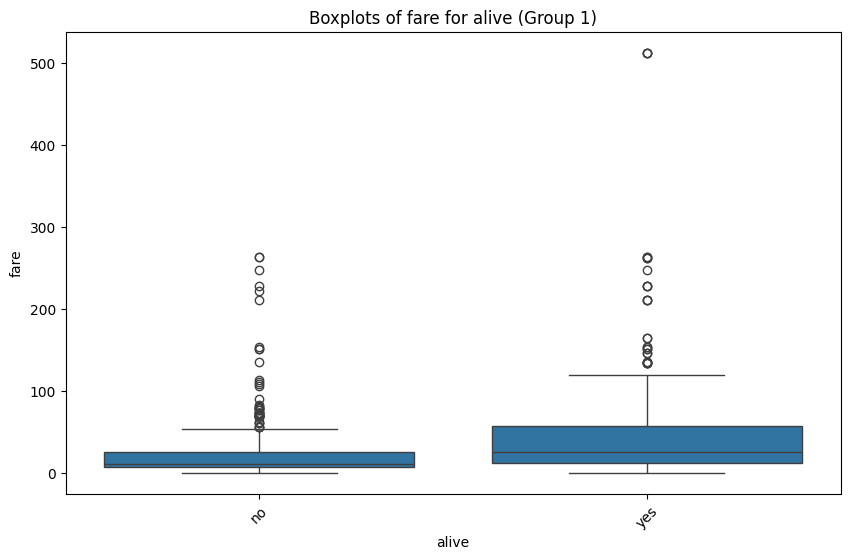

In [125]:
plot_grouped_boxplots(df_titanic,"alive","fare")

A partir de los gráficos analizados, se observan diferencias en la distribución del precio del billete entre los pasajeros que sobrevivieron y los que no. En particular, los supervivientes presentan valores de `fare` más elevados, lo que se refleja tanto en una mediana superior como en una mayor concentración de valores en rangos altos.

El gráfico comparativo de medianas refuerza esta observación, mostrando que el valor central del precio del billete es considerablemente mayor entre los pasajeros que sobrevivieron que entre los que fallecieron.

No obstante, la presencia de una elevada dispersión y de valores atípicos en ambos grupos indica que el precio del billete, aunque relacionado con la supervivencia, no es el único factor determinante.

En consecuencia, los resultados sugieren la existencia de una relación entre ambas variables, que podría estar influida por otras variables como la clase del pasajero.

##### **5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?**

In [126]:
len(df_titanic[df_titanic["fare"] == 0])

15

Dentro del conjunto de pasajeros, se observa que 15 de ellos presentan un valor de `fare` igual a 0. Este hecho puede deberse a diferentes motivos, como posibles errores en el registro de datos, la inclusión de personal del barco o situaciones particulares en las que el billete no requiriese pago.

No obstante, con la información disponible no es posible determinar con certeza la causa de estos valores, por lo que deben interpretarse con cautela en el análisis.

In [127]:
df_titanic.loc[df_titanic["fare"].argmax()]

sex                  female
age                    35.0
sibsp                     0
parch                     0
fare               512.3292
class                 First
who                   woman
adult_male            False
embark_town       Cherbourg
alive                   yes
alone                  True
family_members            0
is_adult               True
Name: 258, dtype: object

A partir de los datos del pasajero que pagó el importe más elevado por su billete (512.32), se observa que se trata de una mujer de 35 años, que embarcó en Cherbourg, viajaba sola, en primera clase, y logró sobrevivir.

##### **6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.**

In [128]:
df_titanic.groupby(["embark_town", "alive"])["fare"].median()

embark_town  alive
Cherbourg    no       14.45830
             yes      56.92920
Queenstown   no        7.75000
             yes       7.80835
Southampton  no       10.50000
             yes      26.00000
Name: fare, dtype: float64

Para los pasajeros que embarcaron en Queenstown no se observan diferencias relevantes en el precio del billete entre quienes sobrevivieron y quienes fallecieron, ya que las medianas son muy similares en ambos grupos.

En cambio, en Southampton y, especialmente, en Cherbourg, se aprecian diferencias más marcadas. En particular, en Cherbourg la mediana del precio del billete de los pasajeros que sobrevivieron es considerablemente superior a la de los que no sobrevivieron.

Estos resultados sugieren que la relación entre el precio del billete y la supervivencia no es homogénea entre las distintas ciudades de embarque, siendo más evidente en Cherbourg.

##### **7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?**

In [129]:
df_titanic["age_group"] = pd.cut(
    df_titanic["age"],
    bins=[0,10,20,30,40,50,60,70,80],
    right=False
)

In [130]:
tabla_abslutos = pd.crosstab(
    [df_titanic["class"], df_titanic["age_group"]],
    df_titanic["alive"]
)
tabla_abslutos.sort_values("yes", ascending=False)

alive              no  yes
class  age_group          
First  [30, 40)    27   53
Third  [30, 40)   156   49
       [20, 30)   102   31
First  [20, 30)    10   24
Second [30, 40)    36   23
       [20, 30)    31   22
First  [40, 50)    15   22
Third  [0, 10)     23   19
Second [0, 10)      0   17
Third  [10, 20)    49   17
First  [10, 20)     3   15
       [50, 60)    12   15
Second [40, 50)     8   10
       [10, 20)     9    9
       [50, 60)    10    5
First  [60, 70)     9    4
Third  [40, 50)    32    2
First  [0, 10)      1    2
Third  [60, 70)     2    1
Second [60, 70)     2    1
First  [70, 80)     3    0
Second [70, 80)     1    0
Third  [50, 60)     6    0
       [70, 80)     2    0

En términos absolutos, la combinación de clase y franja de edad con mayor número de supervivientes corresponde a los pasajeros de entre 30 y 40 años que viajaban en primera clase.

In [131]:
tabla_relativos = pd.crosstab(
    [df_titanic["class"], df_titanic["age_group"]],
    df_titanic["alive"],
    normalize="index"
)

tabla_relativos.sort_values("yes", ascending=False)

alive                   no       yes
class  age_group                    
Second [0, 10)    0.000000  1.000000
First  [10, 20)   0.166667  0.833333
       [20, 30)   0.294118  0.705882
       [0, 10)    0.333333  0.666667
       [30, 40)   0.337500  0.662500
       [40, 50)   0.405405  0.594595
Second [40, 50)   0.444444  0.555556
First  [50, 60)   0.444444  0.555556
Second [10, 20)   0.500000  0.500000
Third  [0, 10)    0.547619  0.452381
Second [20, 30)   0.584906  0.415094
       [30, 40)   0.610169  0.389831
Third  [60, 70)   0.666667  0.333333
Second [50, 60)   0.666667  0.333333
       [60, 70)   0.666667  0.333333
First  [60, 70)   0.692308  0.307692
Third  [10, 20)   0.742424  0.257576
       [30, 40)   0.760976  0.239024
       [20, 30)   0.766917  0.233083
       [40, 50)   0.941176  0.058824
First  [70, 80)   1.000000  0.000000
Second [70, 80)   1.000000  0.000000
Third  [50, 60)   1.000000  0.000000
       [70, 80)   1.000000  0.000000

En términos relativos, la combinación de clase y franja de edad con mayor porcentaje de supervivencia corresponde a los pasajeros de entre 0 y 10 años que viajaban en segunda clase, entre los cuales la tasa de supervivencia alcanza el 100%.

##### **8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?**

In [132]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}
for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor,[col_2,col_1]]

Respuesta no:


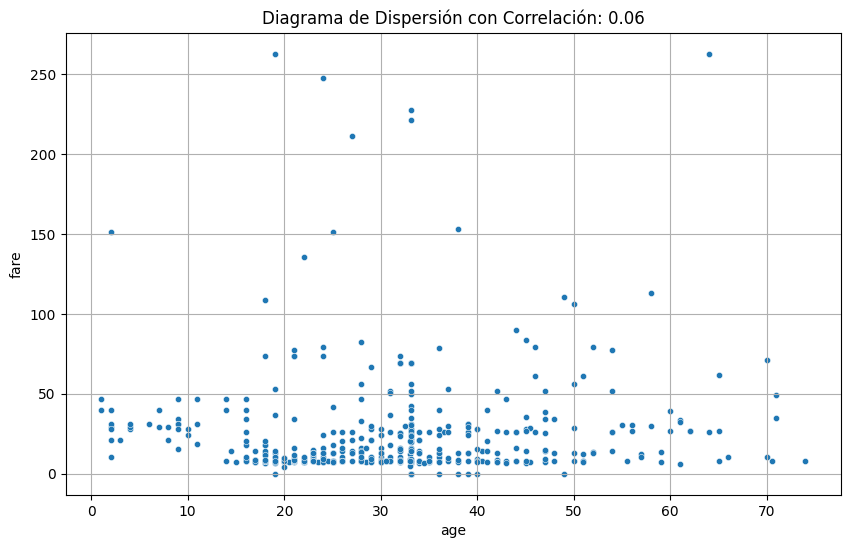

Respuesta yes:


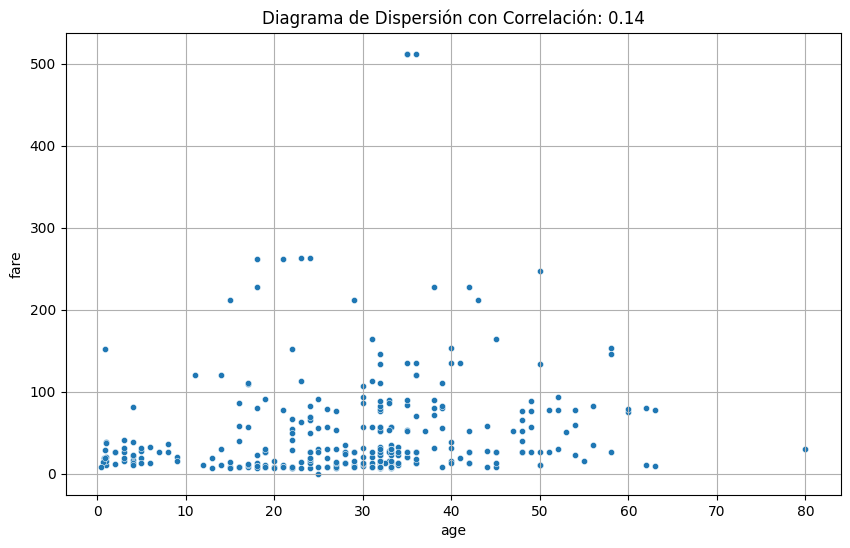

In [133]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

A partir de los diagramas de dispersión, no se observa una relación clara entre la edad y el precio del billete. Los valores aparecen muy dispersos y no muestran una tendencia definida, ni positiva ni negativa, a medida que aumenta cualquiera de las dos variables.

Esto se refuerza con los bajos valores de correlación obtenidos, lo que indica una relación muy débil entre la edad y el coste del billete.

En consecuencia, no parece que la combinación de ambas variables por sí sola permita explicar la probabilidad de supervivencia, siendo necesario considerar otros factores adicionales.

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?